In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE_DRIVE = '/content/drive/MyDrive'
DATASET_DIR = os.path.join(BASE_DRIVE, 'dataset')
OUT_BASE = os.path.join(BASE_DRIVE, 'crop_project')
CKPT_DIR = os.path.join(OUT_BASE, 'checkpoints')
GRADCAM_DIR = os.path.join(OUT_BASE, 'gradcam_outputs')

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

print("DATASET_DIR:", DATASET_DIR)
print("Outputs:", OUT_BASE)


Mounted at /content/drive
DATASET_DIR: /content/drive/MyDrive/dataset
Outputs: /content/drive/MyDrive/crop_project


In [ ]:
import glob
from collections import Counter
from sklearn.model_selection import train_test_split


class_dirs = [d for d in sorted(os.listdir(DATASET_DIR)) if os.path.isdir(os.path.join(DATASET_DIR, d))]
class_names = class_dirs
print("Detected classes:", class_names)

filepaths, labels = [], []
for idx, cname in enumerate(class_names):
    pattern = os.path.join(DATASET_DIR, cname, '**', '*')
    files = glob.glob(pattern, recursive=True)
    files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    filepaths.extend(files)
    labels.extend([idx]*len(files))

print(f"Total valid images: {len(filepaths)}")
print("Images per class:", Counter(labels))


SEED = 42
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, labels, test_size=0.2, stratify=labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)
print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")


Detected classes: ['Cashew', 'Cassava', 'Maize', 'Tomata']
Total valid images: 11375
Images per class: Counter({0: 3496, 1: 3413, 3: 2290, 2: 2176})
Train: 9100, Val: 1137, Test: 1138


In [ ]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_safe(path, label):
    def _decode(path):
        try:
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img, channels=3)
            img = tf.image.resize(img, IMG_SIZE)
            img = img / 255.0
            return img
        except:
            return tf.zeros([*IMG_SIZE,3], tf.float32)
    img = tf.py_function(func=_decode, inp=[path], Tout=tf.float32)
    img.set_shape([*IMG_SIZE,3])
    return img, label


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

def augment(img,label):
    return data_augmentation(img), label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(preprocess_safe, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE).cache()

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(preprocess_safe, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE).cache()

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(preprocess_safe, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam


base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
base_model.trainable = True


for layer in base_model.layers[:15]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,979,396 (57.14 MB)

 Trainable params: 7,344,132 (28.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.8133714694315338), 1: np.float64(0.8333333333333334), 2: np.float64(1.3067202757036187), 3: np.float64(1.2418122270742358)}


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np
import os
import tensorflow as tf


class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


CHECKPOINT_PATH = os.path.join(CKPT_DIR, 'vgg16_best.keras')

callbacks = [
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1, min_lr=1e-7),
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
]


tf.keras.mixed_precision.set_global_policy('mixed_float16')


EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


tf.keras.mixed_precision.set_global_policy('float32')



Class weights: {0: np.float64(0.8133714694315338), 1: np.float64(0.8333333333333334), 2: np.float64(1.3067202757036187), 3: np.float64(1.2418122270742358)}
Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7705 - loss: 0.5398
Epoch 1: val_accuracy improved from -inf to 0.95690, saving model to /content/drive/MyDrive/crop_project/checkpoints/vgg16_best.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 2356s 7s/step - accuracy: 0.7709 - loss: 0.5389 - val_accuracy: 0.9569 - val_loss: 0.0974 - learning_rate: 1.0000e-04
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9537 - loss: 0.1274
Epoch 2: val_accuracy improved from 0.95690 to 0.96746, saving model to /content/drive/MyDrive/crop_project/checkpoints/vgg16_best.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 55s 194ms/step - accuracy: 0.9538 - loss: 0.1273 - val_accuracy: 0.9675 - val_loss: 0.0834 - learning_rate: 1.0000e-04
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9692 - loss: 0.0846
Epoch 3: val_accurac

In [ ]:

final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]


best_val_acc_idx = history.history['val_accuracy'].index(max(history.history['val_accuracy']))
best_val_acc = history.history['val_accuracy'][best_val_acc_idx]
best_val_loss = history.history['val_loss'][best_val_acc_idx]

print(f"Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Validation Loss at Best Accuracy: {best_val_loss:.4f}")


Final Training Accuracy: 98.84%
Final Training Loss: 0.0341
Best Validation Accuracy: 97.98%
Validation Loss at Best Accuracy: 0.0618


36/36 ━━━━━━━━━━━━━━━━━━━━ 250s 7s/step - accuracy: 0.9789 - loss: 0.0600
Test Accuracy: 0.9797890782356262
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/ste

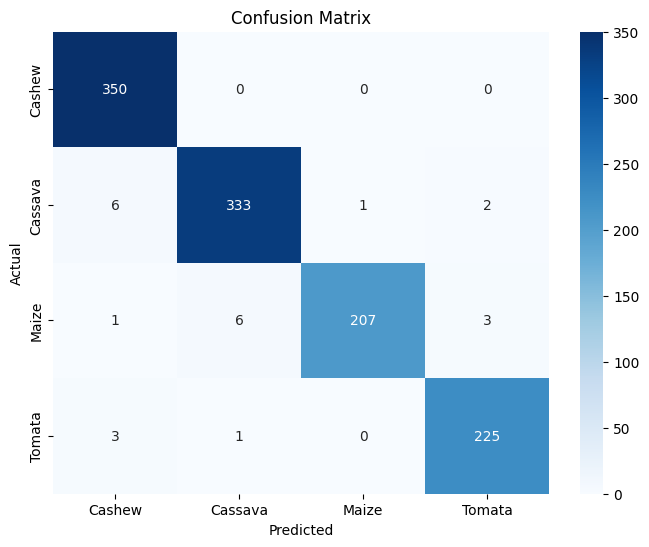

              precision    recall  f1-score   support

      Cashew       0.97      1.00      0.99       350
     Cassava       0.98      0.97      0.98       342
       Maize       1.00      0.95      0.97       217
      Tomata       0.98      0.98      0.98       229

    accuracy                           0.98      1138
   macro avg       0.98      0.98      0.98      1138
weighted avg       0.98      0.98      0.98      1138



In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


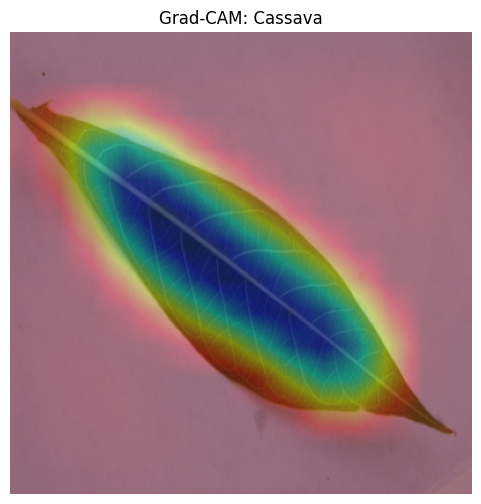

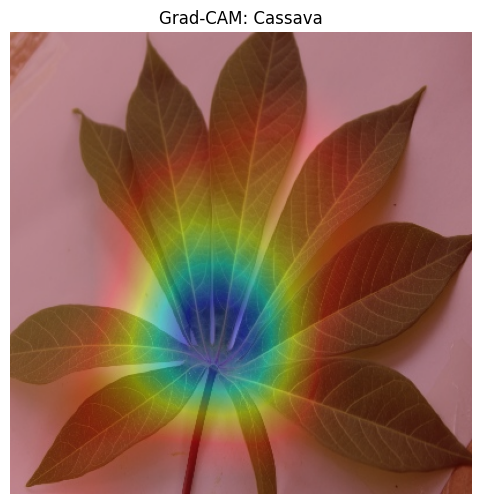

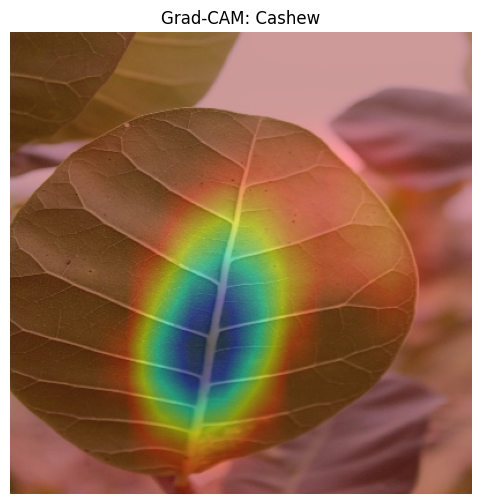

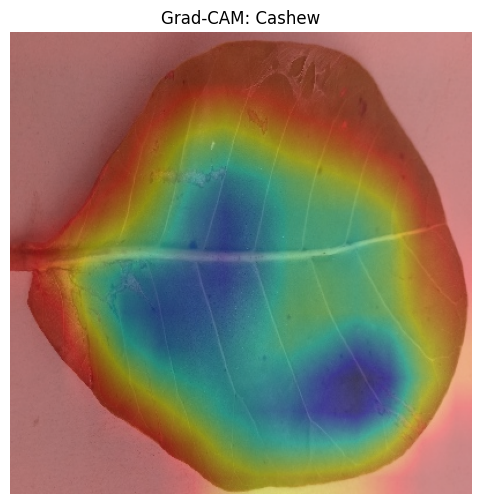

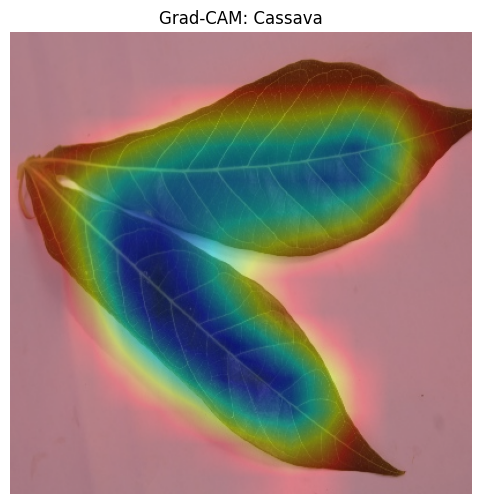

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


def get_gradcam(model, img_tensor, last_conv_layer="block5_conv3"):
    """
    Compute Grad-CAM heatmap and predicted class index.
    """
    vgg_base = model.layers[0]
    classifier = tf.keras.Sequential(model.layers[1:])


    grad_model = tf.keras.models.Model(
        inputs=vgg_base.input,
        outputs=[vgg_base.get_layer(last_conv_layer).output, classifier(vgg_base.output)]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), class_idx.numpy()


for imgs, labels in test_ds.take(1):
    _ = model(imgs)


for i, path in enumerate(test_paths[:5]):
    img = cv2.imread(path)
    img_resized = cv2.resize(img, IMG_SIZE)
    img_tensor = tf.expand_dims(tf.cast(img_resized/255.0, tf.float32), axis=0)

    heatmap, class_idx = get_gradcam(model, img_tensor)


    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)


    overlay = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM: {class_names[class_idx]}")
    plt.axis('off')
    plt.show()
